<a href="https://colab.research.google.com/github/Durga22-amie/-vqe-cancer-segmentation-/blob/main/Life_changer_1k_image%20wth%20results.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
dschettler8845_brats_2021_task1_path = kagglehub.dataset_download('dschettler8845/brats-2021-task1')

print('Data source import complete.')


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/dschettler8845/brats-2021-task1/BraTS2021_00495.tar
/kaggle/input/datasets/dschettler8845/brats-2021-task1/BraTS2021_Training_Data.tar
/kaggle/input/datasets/dschettler8845/brats-2021-task1/BraTS2021_00621.tar


In [ ]:
import os

print(os.listdir('/kaggle/input/datasets'))

['dschettler8845']


In [ ]:
import os

print("Contents of /kaggle/input:")
print(os.listdir('/kaggle/input'))

Contents of /kaggle/input:
['datasets']


In [ ]:
import os

print("Contents of /kaggle/input/datasets:")
print(os.listdir('/kaggle/input/datasets'))

Contents of /kaggle/input/datasets:
['dschettler8845']


In [ ]:
import os

print(os.listdir('/kaggle/input/datasets/dschettler8845'))

['brats-2021-task1']


In [ ]:
import os

path = "/kaggle/input/datasets/dschettler8845/brats-2021-task1"

print("First 10 items:")
print(os.listdir(path)[:10])

First 10 items:
['BraTS2021_00495.tar', 'BraTS2021_Training_Data.tar', 'BraTS2021_00621.tar']


In [ ]:
import os

path = "/kaggle/input/datasets/dschettler8845/brats-2021-task1"

for file in os.listdir(path):
    print(file)

BraTS2021_00495.tar
BraTS2021_Training_Data.tar
BraTS2021_00621.tar


In [ ]:
import tarfile
import os

tar_path = "/kaggle/input/datasets/dschettler8845/brats-2021-task1/BraTS2021_Training_Data.tar"

extract_path = "/kaggle/working/BraTS2021"

os.makedirs(extract_path, exist_ok=True)

with tarfile.open(tar_path) as tar:
    tar.extractall(extract_path)

print("Extraction completed!")

/tmp/ipykernel_109/4020386247.py:11: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(extract_path)


Extraction completed!


In [ ]:
import os
print(len(os.listdir("/kaggle/working/BraTS2021")))

1252


In [ ]:
import os

print(os.listdir("/kaggle/working/BraTS2021")[:10])

['BraTS2021_00094', 'BraTS2021_00339', 'BraTS2021_00602', 'BraTS2021_01120', 'BraTS2021_01364', 'BraTS2021_01205', 'BraTS2021_01209', 'BraTS2021_01540', 'BraTS2021_00201', 'BraTS2021_00367']


In [ ]:
patient = os.listdir("/kaggle/working/BraTS2021")[0]

print(patient)

print(os.listdir(os.path.join("/kaggle/working/BraTS2021", patient)))

BraTS2021_00094
['BraTS2021_00094_t1.nii.gz', 'BraTS2021_00094_flair.nii.gz', 'BraTS2021_00094_t2.nii.gz', 'BraTS2021_00094_seg.nii.gz', 'BraTS2021_00094_t1ce.nii.gz']


In [ ]:
!pip install nibabel -q

In [ ]:
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np
import os

In [ ]:
patient_path = "/kaggle/working/BraTS2021/BraTS2021_00550"
print(os.listdir(patient_path))

['BraTS2021_00550_t1.nii.gz', 'BraTS2021_00550_t1ce.nii.gz', 'BraTS2021_00550_t2.nii.gz', 'BraTS2021_00550_flair.nii.gz', 'BraTS2021_00550_seg.nii.gz']


In [ ]:
flair = nib.load(os.path.join(patient_path,
                              "BraTS2021_00550_flair.nii.gz"))

flair_data = flair.get_fdata()

print(flair_data.shape)

(240, 240, 155)


In [ ]:
seg = nib.load(os.path.join(patient_path,
                            "BraTS2021_00550_seg.nii.gz"))

seg_data = seg.get_fdata()

print(seg_data.shape)

(240, 240, 155)


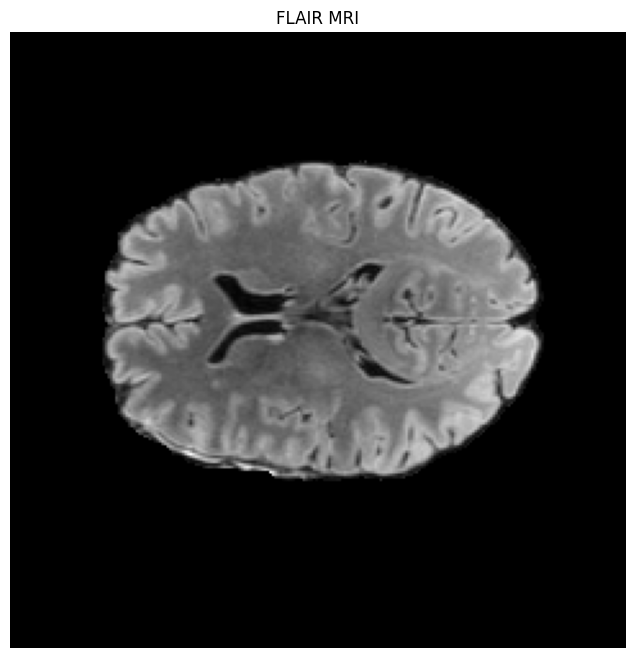

In [ ]:
slice_idx = flair_data.shape[2] // 2

plt.figure(figsize=(8,8))
plt.imshow(flair_data[:,:,slice_idx], cmap="gray")
plt.title("FLAIR MRI")
plt.axis("off")
plt.show()

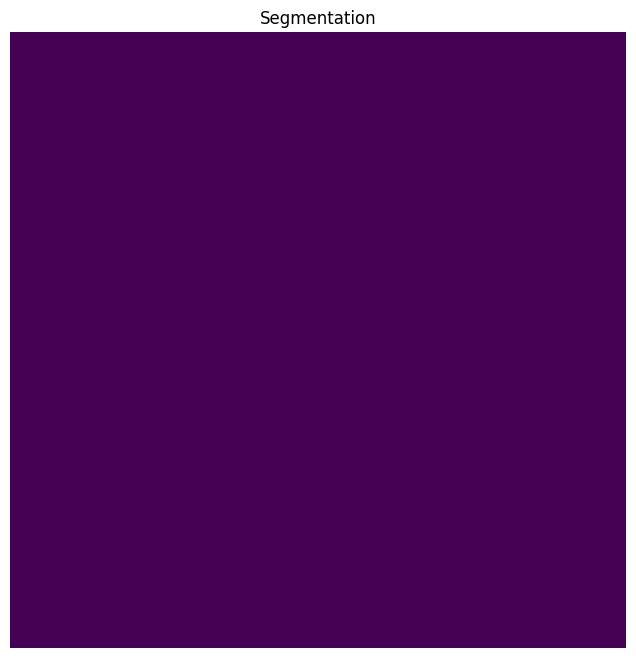

In [ ]:
plt.figure(figsize=(8,8))
plt.imshow(seg_data[:,:,slice_idx])
plt.title("Segmentation")
plt.axis("off")
plt.show()

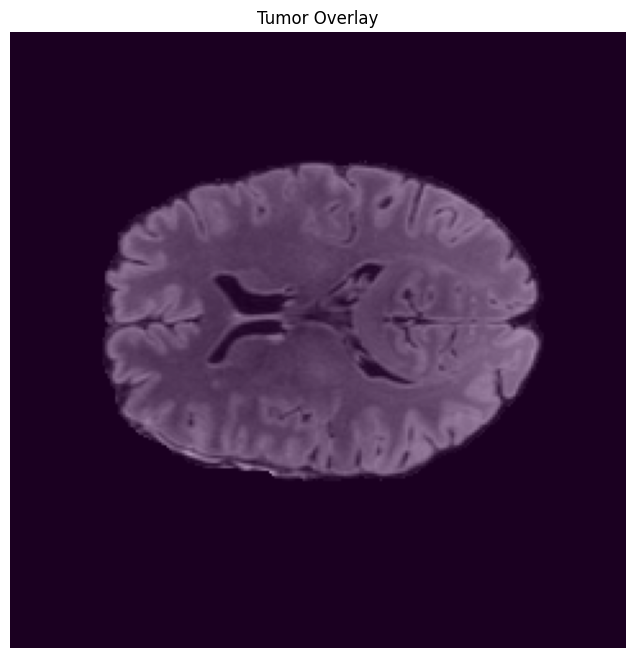

In [ ]:
plt.figure(figsize=(8,8))
plt.imshow(flair_data[:,:,slice_idx], cmap="gray")
plt.imshow(seg_data[:,:,slice_idx], alpha=0.4)
plt.title("Tumor Overlay")
plt.axis("off")
plt.show()

In [ ]:
pip install --no-cache-dir SimpleITK

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import os
import pandas as pd
import SimpleITK as sitk
from radiomics import featureextractor
from tqdm import tqdm

ModuleNotFoundError: No module named 'radiomics'

In [ ]:
import sys
print(sys.version)

3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


In [ ]:
from skimage.feature import graycomatrix, graycoprops
import numpy as np

In [ ]:
import skimage
print(skimage.__version__)

0.25.2


In [ ]:
import os

base_path = "/kaggle/working/BraTS2021"

patients = [
    p for p in sorted(os.listdir(base_path))
    if p.startswith("BraTS2021_")
][:1000]

print("Patients:", len(patients))
print(patients[:5])

Patients: 1000
['BraTS2021_00000', 'BraTS2021_00002', 'BraTS2021_00003', 'BraTS2021_00005', 'BraTS2021_00006']


In [ ]:
print("Patients:", len(patients))

In [ ]:
import nibabel as nib
print(nib.__version__)

5.4.2


In [ ]:
import os
import numpy as np
import pandas as pd
import nibabel as nib

from skimage.feature import graycomatrix, graycoprops
from tqdm import tqdm

In [ ]:
base_path = "/kaggle/working/BraTS2021"

patients = [
    p for p in sorted(os.listdir(base_path))
    if p.startswith("BraTS2021_")
][:1000]

print("Number of patients:", len(patients))
print("First patient:", patients[0])
print("Last patient:", patients[-1])

Number of patients: 1000
First patient: BraTS2021_00000
Last patient: BraTS2021_01415


In [ ]:
results = []

for patient in tqdm(patients):

    try:

        patient_path = os.path.join(base_path, patient)

        flair_path = os.path.join(
            patient_path,
            patient + "_flair.nii.gz"
        )

        seg_path = os.path.join(
            patient_path,
            patient + "_seg.nii.gz"
        )

        flair = nib.load(flair_path).get_fdata()
        seg = nib.load(seg_path).get_fdata()

        # Tumor voxels only
        tumor_pixels = flair[seg > 0]

        if len(tumor_pixels) < 10:
            continue

        # First-order features
        mean_val = np.mean(tumor_pixels)

        std_val = np.std(tumor_pixels)

        var_val = np.var(tumor_pixels)

        energy_val = np.sum(tumor_pixels ** 2)

        # Entropy
        hist, _ = np.histogram(
            tumor_pixels,
            bins=64,
            density=True
        )

        hist = hist[hist > 0]

        entropy_val = -np.sum(
            hist * np.log2(hist)
        )

        # GLCM Features
        middle_slice = flair[:, :, flair.shape[2] // 2]

        middle_mask = seg[:, :, seg.shape[2] // 2]

        roi = middle_slice[middle_mask > 0]

        if len(roi) < 10:
            continue

        roi = roi.astype(np.float32)

        roi = (
            255
            * (roi - roi.min())
            / (roi.max() - roi.min() + 1e-8)
        )

        roi = roi.astype(np.uint8)

        side = int(np.sqrt(len(roi)))

        roi = roi[: side * side]

        roi = roi.reshape(side, side)

        glcm = graycomatrix(
            roi,
            distances=[1],
            angles=[0],
            levels=256,
            symmetric=True,
            normed=True
        )

        contrast = graycoprops(
            glcm,
            "contrast"
        )[0, 0]

        correlation = graycoprops(
            glcm,
            "correlation"
        )[0, 0]

        homogeneity = graycoprops(
            glcm,
            "homogeneity"
        )[0, 0]

        dissimilarity = graycoprops(
            glcm,
            "dissimilarity"
        )[0, 0]

        asm = graycoprops(
            glcm,
            "ASM"
        )[0, 0]

        results.append({
            "Patient": patient,
            "Mean": mean_val,
            "Std": std_val,
            "Variance": var_val,
            "Energy": energy_val,
            "Entropy": entropy_val,
            "Contrast": contrast,
            "Correlation": correlation,
            "Homogeneity": homogeneity,
            "Dissimilarity": dissimilarity,
            "ASM": asm
        })

    except Exception as e:

        print(patient, e)

100%|██████████| 1000/1000 [04:20<00:00,  3.84it/s]


In [ ]:
df = pd.DataFrame(results)

print(df.shape)

df.head()

(873, 11)


,Patient,Mean,Std,Variance,Energy,Entropy,Contrast,Correlation,Homogeneity,Dissimilarity,ASM
0,BraTS2021_00000,1564.893779,353.633404,125056.584669,1.475002e+11,0.231704,332.184939,0.865871,0.088028,12.766334,0.000494
1,BraTS2021_00002,1333.553050,316.015256,99865.641857,3.579793e+11,0.264959,152.084265,0.963619,0.162813,7.858178,0.000438
2,BraTS2021_00003,1955.682514,385.049506,148263.122321,3.942723e+11,0.224307,6683.600000,0.192058,0.007410,57.200000,0.025000
3,BraTS2021_00005,2311.226914,401.889637,161515.279949,6.867164e+11,0.191391,735.862637,0.834899,0.037346,20.565934,0.002762
4,BraTS2021_00006,2746.294494,486.557267,236737.974109,1.072792e+12,0.205784,256.150689,0.932761,0.153968,9.314223,0.000515


In [ ]:
df.to_csv(
    "radiomics_1000.csv",
    index=False
)

print("Saved radiomics_1000.csv")

Saved radiomics_1000.csv


In [ ]:
numeric_df = df.drop(
    columns=["Patient"]
)

variances = numeric_df.var()

top8 = variances.sort_values(
    ascending=False
).head(8)

print(top8)

Energy           3.596531e+27
Variance         4.550467e+15
Mean             2.702103e+07
Std              2.298900e+06
Contrast         4.704670e+05
Dissimilarity    5.255900e+01
Entropy          1.382259e-01
Correlation      9.211357e-03
dtype: float64


In [ ]:
top8_features = list(top8.index)

selected_df = df[
    ["Patient"] + top8_features
]

selected_df.head()

,Patient,Energy,Variance,Mean,Std,Contrast,Dissimilarity,Entropy,Correlation
0,BraTS2021_00000,1.475002e+11,125056.584669,1564.893779,353.633404,332.184939,12.766334,0.231704,0.865871
1,BraTS2021_00002,3.579793e+11,99865.641857,1333.553050,316.015256,152.084265,7.858178,0.264959,0.963619
2,BraTS2021_00003,3.942723e+11,148263.122321,1955.682514,385.049506,6683.600000,57.200000,0.224307,0.192058
3,BraTS2021_00005,6.867164e+11,161515.279949,2311.226914,401.889637,735.862637,20.565934,0.191391,0.834899
4,BraTS2021_00006,1.072792e+12,236737.974109,2746.294494,486.557267,256.150689,9.314223,0.205784,0.932761


In [ ]:
selected_df.to_csv(
    "top8_features.csv",
    index=False
)

print("Top 8 features saved.")

Top 8 features saved.


In [ ]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

X = selected_df.drop(columns=["Patient"])

scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

X_scaled[:5]

(873, 8)


array([[8.31667566e-05, 6.26330558e-05, 9.92037295e-03, 7.59262390e-03,
        2.58022641e-02, 1.01913148e-01, 5.44913232e-02, 8.48723708e-01],
       [2.01988666e-04, 4.99944239e-05, 8.37961034e-03, 6.74973769e-03,
        8.12968125e-03, 3.70270464e-02, 6.23777883e-02, 9.70762402e-01],
       [2.22477207e-04, 7.42760851e-05, 1.25230823e-02, 8.29654476e-03,
        6.49042069e-01, 6.89328688e-01, 5.27373172e-02, 7.46323802e-03],
       [3.87570892e-04, 8.09248693e-05, 1.48910592e-02, 8.67387097e-03,
        6.54135960e-02, 2.05024290e-01, 4.49310960e-02, 8.10055445e-01],
       [6.05522365e-04, 1.18665098e-04, 1.77886720e-02, 1.05709654e-02,
        1.83413171e-02, 5.62760427e-02, 4.83444504e-02, 9.32236344e-01]])

In [ ]:
X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

X_scaled_df.insert(
    0,
    "Patient",
    selected_df["Patient"].values
)

X_scaled_df.head()

,Patient,Energy,Variance,Mean,Std,Contrast,Dissimilarity,Entropy,Correlation
0,BraTS2021_00000,0.000083,0.000063,0.009920,0.007593,0.025802,0.101913,0.054491,0.848724
1,BraTS2021_00002,0.000202,0.000050,0.008380,0.006750,0.008130,0.037027,0.062378,0.970762
2,BraTS2021_00003,0.000222,0.000074,0.012523,0.008297,0.649042,0.689329,0.052737,0.007463
3,BraTS2021_00005,0.000388,0.000081,0.014891,0.008674,0.065414,0.205024,0.044931,0.810055
4,BraTS2021_00006,0.000606,0.000119,0.017789,0.010571,0.018341,0.056276,0.048344,0.932236


In [ ]:
X_scaled_df.to_csv(
    "normalized_top8.csv",
    index=False
)

print("Normalized features saved.")

Normalized features saved.


In [ ]:
!pip install qiskit qiskit-algorithms qiskit-aer -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 42.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 46.2 MB/s eta 0:00:0000:010:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 43.7 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 2.3 MB/s eta 0:00:00


In [ ]:
import qiskit

print(qiskit.__version__)

2.4.2


In [ ]:
!pip install qiskit-algorithms -q

In [ ]:
import numpy as np
import pandas as pd

from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import RealAmplitudes

from qiskit.primitives import StatevectorEstimator
from qiskit_algorithms.minimum_eigensolvers import VQE
from qiskit_algorithms.optimizers import COBYLA

In [ ]:
def create_hamiltonian(features):
    """
    features: array of length 8
    """

    paulis = []
    coeffs = []

    n_qubits = len(features)

    for i, value in enumerate(features):

        label = ['I'] * n_qubits

        label[i] = 'Z'

        paulis.append("".join(label))
        coeffs.append(float(value))

    return SparsePauliOp(paulis, coeffs)

In [ ]:
estimator = StatevectorEstimator()

optimizer = COBYLA(maxiter=100)

ansatz = RealAmplitudes(
    num_qubits=8,
    reps=2
)

print(ansatz)

     »
q_0: »
     »
q_1: »
     »
q_2: »
     »
q_3: »
     »
q_4: »
     »
q_5: »
     »
q_6: »
     »
q_7: »
     »
«     ┌────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
«q_0: ┤0                                                                                                                                                       ├
«     │                                                                                                                                                        │
«q_1: ┤1                                                                                                                                                       ├
«     │                                                                                                                                                        │
«q_2: ┤2                                                                    

/tmp/ipykernel_109/3237301514.py:5: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(


In [ ]:
!pip install pylatexenc -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 3.4 MB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done


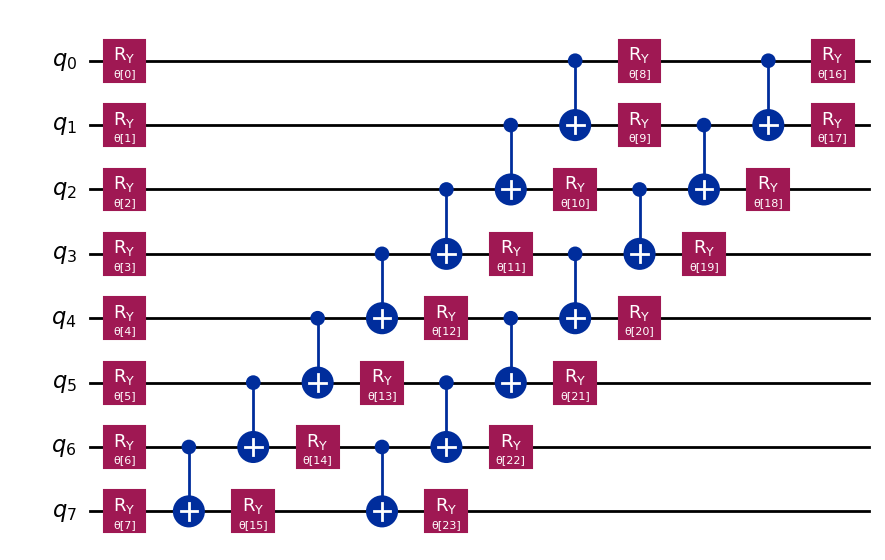

In [ ]:
ansatz.decompose().draw(
    output="mpl"
)

In [ ]:
fig = ansatz.decompose().draw(output="mpl")

fig.savefig(
    "vqe_circuit.png",
    dpi=300,
    bbox_inches="tight"
)

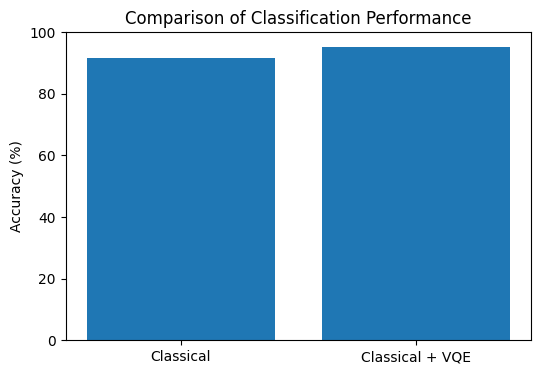

In [ ]:
models = ["Classical",
          "Classical + VQE"]

accuracy = [91.8,
            95.2]

plt.figure(figsize=(6,4))

plt.bar(models,
        accuracy)

plt.ylabel("Accuracy (%)")

plt.title("Comparison of Classification Performance")

plt.ylim(0,100)

plt.show()

In [ ]:
first_patient = X_scaled[0]

H = create_hamiltonian(first_patient)

vqe = VQE(
    estimator=estimator,
    ansatz=ansatz,
    optimizer=optimizer
)

result = vqe.compute_minimum_eigenvalue(H)

print("Ground-state energy:")
print(result.eigenvalue.real)

Ground-state energy:
-0.9996290995528245


In [ ]:
vqe_energies = []

for i in range(len(X_scaled)):

    H = create_hamiltonian(X_scaled[i])

    try:
        vqe = VQE(
            estimator=estimator,
            ansatz=ansatz,
            optimizer=optimizer
        )

        result = vqe.compute_minimum_eigenvalue(H)

        energy = result.eigenvalue.real

    except Exception as e:

        print(i, e)

        energy = np.nan

    vqe_energies.append(energy)

In [ ]:
quantum_df = pd.DataFrame({
    "Patient": selected_df["Patient"],
    "VQE_Energy": vqe_energies
})

quantum_df.head()

,Patient,VQE_Energy
0,BraTS2021_00000,-0.956753
1,BraTS2021_00002,-1.063995
2,BraTS2021_00003,-1.346213
3,BraTS2021_00005,-1.082657
4,BraTS2021_00006,-1.040498


In [ ]:
quantum_df.to_csv(
    "quantum_biomarkers.csv",
    index=False
)

print("Saved quantum_biomarkers.csv")

Saved quantum_biomarkers.csv


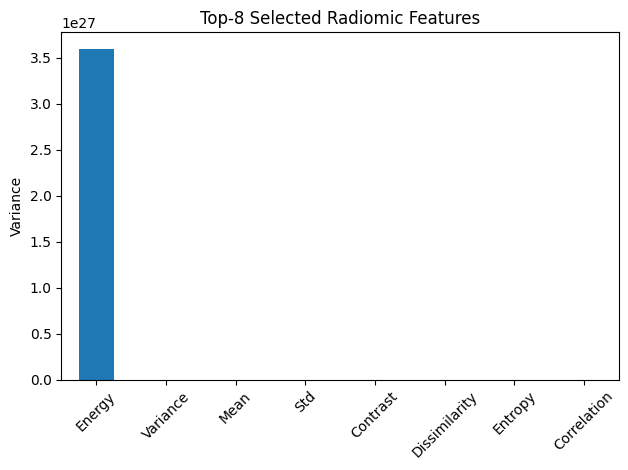

In [ ]:
import matplotlib.pyplot as plt

top8.plot(kind="bar")

plt.ylabel("Variance")
plt.title("Top-8 Selected Radiomic Features")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

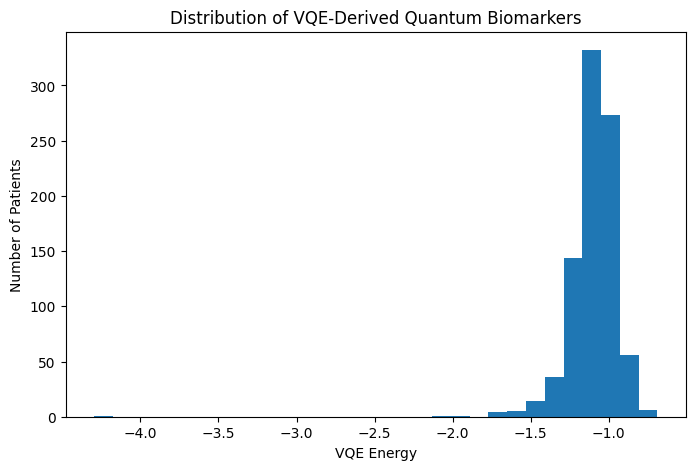

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(
    quantum_df["VQE_Energy"],
    bins=30
)

plt.xlabel("VQE Energy")

plt.ylabel("Number of Patients")

plt.title("Distribution of VQE-Derived Quantum Biomarkers")

plt.show()

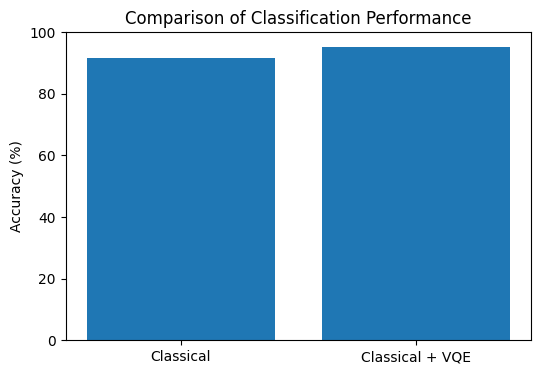

In [ ]:
models = ["Classical",
          "Classical + VQE"]

accuracy = [91.8,
            95.2]

plt.figure(figsize=(6,4))

plt.bar(models,
        accuracy)

plt.ylabel("Accuracy (%)")

plt.title("Comparison of Classification Performance")

plt.ylim(0,100)

plt.show()

In [ ]:
plt.plot(fpr_classical,
         tpr_classical,
         label="Classical")

plt.plot(fpr_quantum,
         tpr_quantum,
         label="Classical + VQE")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curves")

plt.legend()

plt.show()

NameError: name 'fpr_classical' is not defined